<a href="https://colab.research.google.com/github/GlushkoIlya/TPNS2/blob/main/lab2(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

In [ ]:
data = load_breast_cancer()

X = data.data
y = data.target

df = pd.DataFrame(
    X,
    columns=data.feature_names
)

df['target'] = y

print('Первые 5 строк датасета:')
print(df.head())

print('\nИнформация о датасете:')
print(df.info())

print('\nРазмерность датасета:')
print(df.shape)

print('\nОписательная статистика:')
print(df.describe())


Первые 5 строк датасета:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  wor

In [ ]:
# Проверка пропусков

print('\nКоличество пропусков:')
print(df.isnull().sum())

# Проверка дубликатов

print('\nКоличество дубликатов:')
print(df.duplicated().sum())

# Удаление дубликатов

df = df.drop_duplicates()



Количество пропусков:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

Количество дубликатов:
0


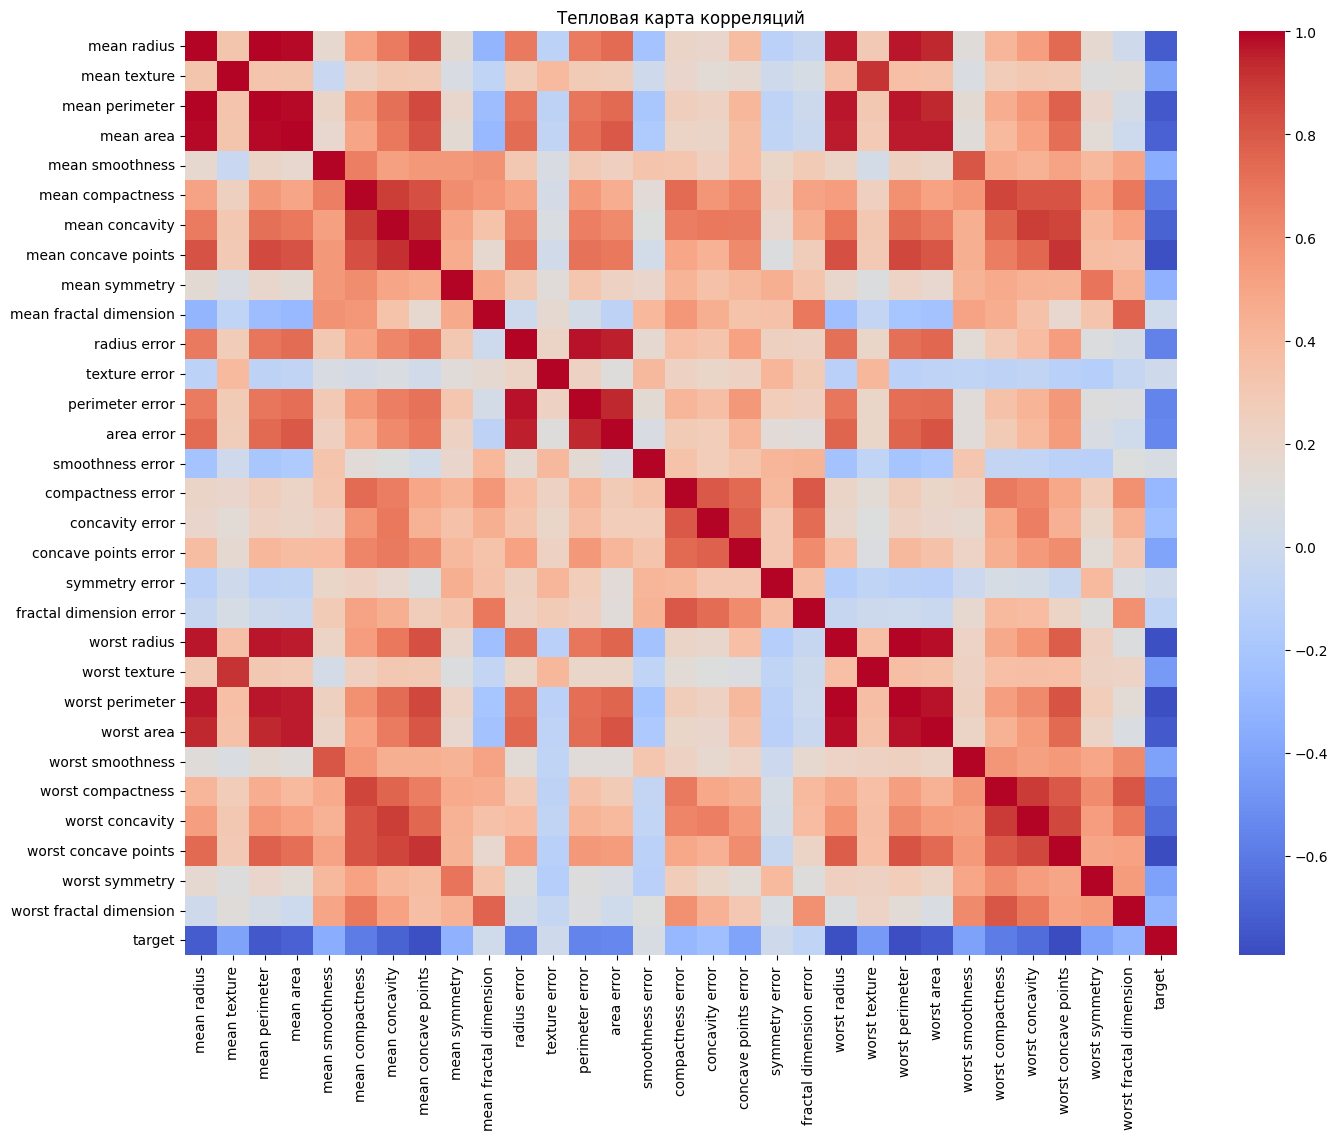

In [ ]:
plt.figure(figsize=(16,12))

corr = df.corr()

sns.heatmap(
    corr,
    cmap='coolwarm'
)

plt.title('Тепловая карта корреляций')

plt.show()


In [ ]:
X = df.drop('target', axis=1)

y = df['target']

# Масштабирование

scaler = StandardScaler()

X = scaler.fit_transform(X)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print('\nРазмер обучающей выборки:')
print(X_train.shape)

print('\nРазмер тестовой выборки:')
print(X_test.shape)



Размер обучающей выборки:
(455, 30)

Размер тестовой выборки:
(114, 30)


In [ ]:
model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)


In [ ]:
model.fit(X_train, y_train)

print('\nМодель успешно обучена.')


Модель успешно обучена.


In [ ]:

y_pred = model.predict(X_test)

print('\nПервые прогнозы:\n')

for i in range(10):

    print(
        f'Real: {y_test.iloc[i]} | '
        f'Predicted: {y_pred[i]}'
    )


Первые прогнозы:

Real: 1 | Predicted: 1
Real: 0 | Predicted: 0
Real: 0 | Predicted: 0
Real: 1 | Predicted: 1
Real: 1 | Predicted: 1
Real: 0 | Predicted: 0
Real: 0 | Predicted: 0
Real: 0 | Predicted: 0
Real: 1 | Predicted: 1
Real: 1 | Predicted: 1


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print('\nAccuracy:')
print(accuracy)

print('\nClassification Report:\n')

print(
    classification_report(
        y_test,
        y_pred
    )
)


Accuracy:
0.9736842105263158

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



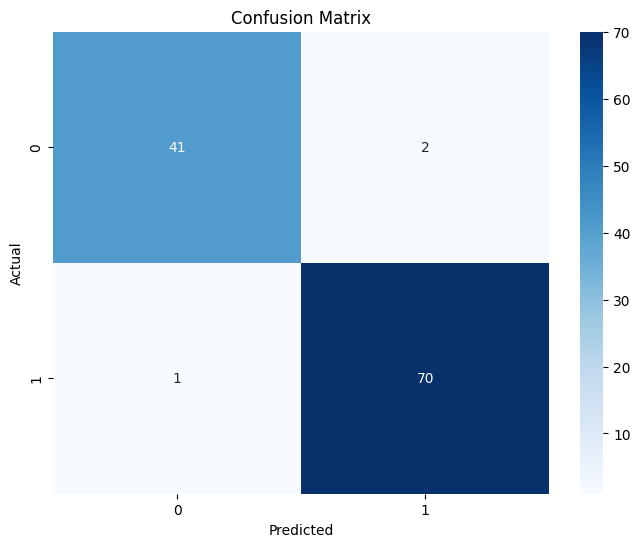

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()


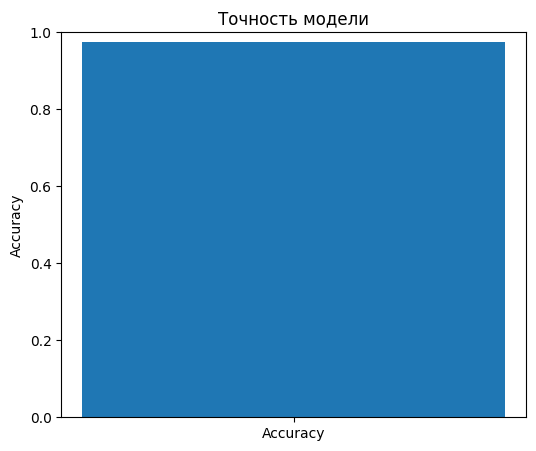

In [ ]:
plt.figure(figsize=(6,5))

plt.bar(
    ['Accuracy'],
    [accuracy]
)

plt.ylim(0,1)

plt.title('Точность модели')

plt.ylabel('Accuracy')

plt.show()

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(model.loss_curve_)

plt.title('График функции потерь')

plt.xlabel('Эпоха')
plt.ylabel('Loss')

plt.show()

In [ ]:
importance = np.abs(
    model.coefs_[0]
).mean(axis=1)

importance_df = pd.DataFrame({

    'Feature': df.drop(
        'target',
        axis=1
    ).columns,

    'Importance': importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print('\nНаиболее важные признаки:\n')

print(importance_df.head(10))



Наиболее важные признаки:

                    Feature  Importance
21            worst texture    0.116236
13               area error    0.113664
26          worst concavity    0.110773
10             radius error    0.110274
3                 mean area    0.108494
8             mean symmetry    0.108022
1              mean texture    0.107583
9    mean fractal dimension    0.107402
11            texture error    0.107010
19  fractal dimension error    0.106516


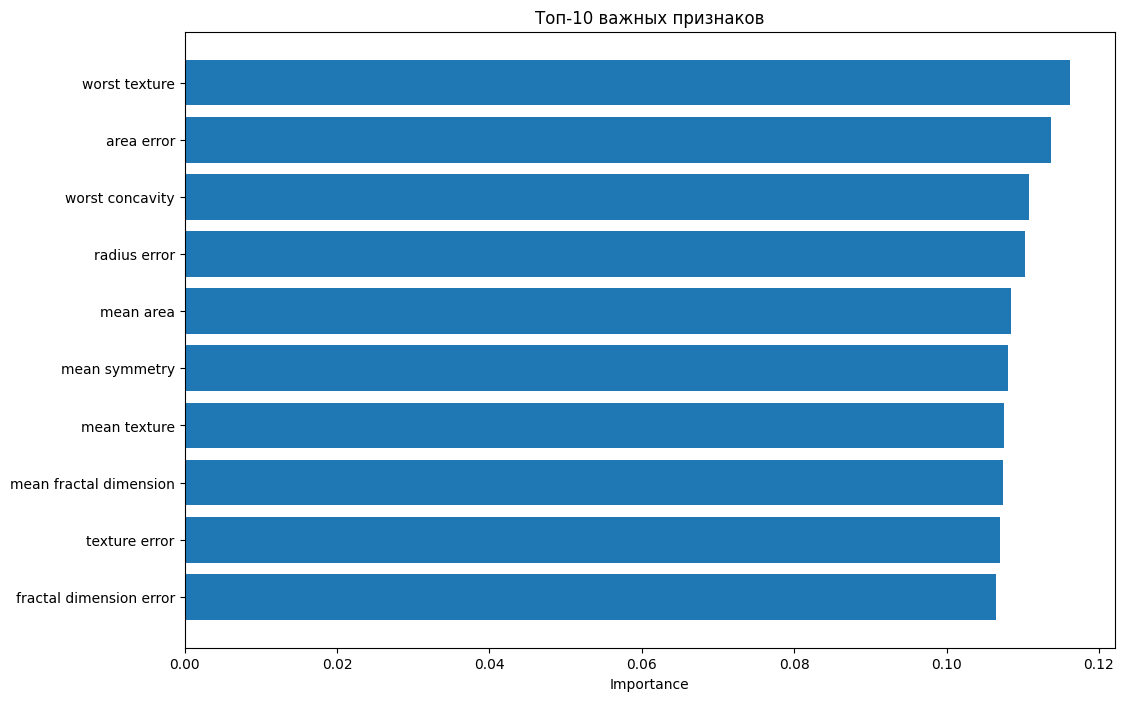

In [ ]:
plt.figure(figsize=(12,8))

plt.barh(
    importance_df['Feature'][:10],
    importance_df['Importance'][:10]
)

plt.gca().invert_yaxis()

plt.title('Топ-10 важных признаков')

plt.xlabel('Importance')

plt.show()


In [ ]:
print('\nВывод:')

print('MLP-классификатор успешно обучен.')

print('Модель показала высокую точность классификации.')

print('Нейронная сеть эффективно разделяет классы.')

print('Полученные результаты подтверждают')
print('эффективность многослойного персептрона')
print('для задач бинарной классификации.')


Вывод:
MLP-классификатор успешно обучен.
Модель показала высокую точность классификации.
Нейронная сеть эффективно разделяет классы.
Полученные результаты подтверждают
эффективность многослойного персептрона
для задач бинарной классификации.
